In [1]:
import sys
sys.path.append('../')

In [2]:
import joblib
import matplotlib.pyplot as pyplot
import shap
from pathlib import Path
from sklearn.metrics import accuracy_score, classification_report
from src.data_processing_XGBoost import load_data

c:\Users\Utilisateur\Documents\GitHub\Cancer-CODING-WEEK\.venv-1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import xgboost as xgb

model = xgb.XGBClassifier()
model.load_model('../data/xgboost_model.json')

X_train, X_test, y_train, y_test = load_data()

ℹ️ Fichiers splittés déjà présents. Chargement...


In [4]:
data_dir = Path('../data')

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# SHAP : importance des features (bar chart)
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)   # nouvelle API SHAP
shap.plots.bar(shap_values, max_display=10, show=False)  # top 10 features
pyplot.tight_layout()
pyplot.savefig(data_dir / "shap_summary_bar_plot.png")
pyplot.close()

Accuracy: 0.9534883720930233
              precision    recall  f1-score   support

           0       0.98      0.97      0.97       161
           1       0.62      0.73      0.67        11

    accuracy                           0.95       172
   macro avg       0.80      0.85      0.82       172
weighted avg       0.96      0.95      0.96       172



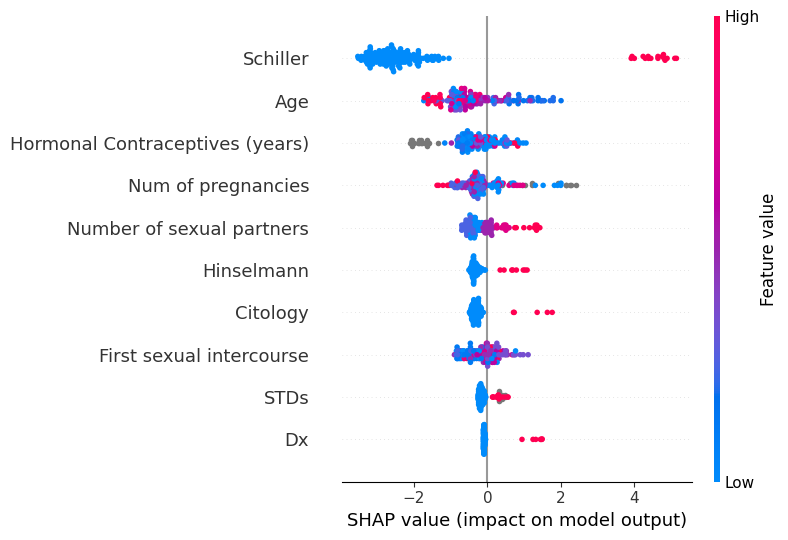

In [5]:
# Visualisation SHAP : summary plot
shap.summary_plot(shap_values, X_test, max_display=10)